# Análisis Operativo de Helpdesk — IT Service Management
## Notebook 2 de 2: Análisis, Visualizaciones y Conclusiones de Negocio

**Autora:** Camila Gámez · Data Analyst  
**Dependencia:** Ejecutar primero `01_extraccion_transformacion.ipynb`  
**Datos reales confirmados:** 32,726 tickets · 6 archivos exports generados

---

## 1. Contexto (resumen)

Este notebook es la etapa analítica del proyecto. Los datos ya fueron extraídos, limpiados
y exportados en el Notebook 1. Aquí se responden las preguntas de negocio con evidencia
estadística y visualizaciones, y se construyen las conclusiones con impacto directo en costos
y retención de clientes.

---

## 2. KPIs analizados en este notebook

| KPI | Valor real (del Notebook 1) | Análisis aquí |
|---|---|---|
| **MTTR mediana** | Blocker: 90.6h · Medium: 238.5h | Paso 7: visual + comparación |
| **Shapiro-Wilk** | W=0.329, p<0.001 → No normal | Paso 8: justifica Mann-Whitney |
| **Mann-Whitney U** | p=3.6e-147 → Significativo | Paso 9: valida diferencia de MTTR |
| **Ticket Churn** | Low: 4.82% · Blocker: 2.29% | Paso 10: patrón contraintuitivo |
| **FCR** | 57.1% | Paso 11: análisis por prioridad |
| **Escalation Rate** | 42.9% | Paso 11: costo real en horas |
| **SLA Compliance** | Blocker: 22.5% | Paso 12: brecha crítica |
| **Ticket Volume YoY** | +382% (2018→2022) | Paso 13: tendencia y capacidad |
| **Avg Processing Steps** | 4.0 pasos mediana | Paso 14: complejidad por tipo |
| **Externo vs Interno** | Blocker ext: 72.6h vs int: 6470h | Paso 15: anomalía documentada |
| **Correlación Spearman** | r=0.113, p<0.001 | Paso 16: steps vs MTTR |
| **Risk Score compuesto** | Índice 0–10 por prioridad | Paso 17: segmentación de riesgo |

---

## 3. Paso a paso de este notebook

```
PASO 7  · MTTR por prioridad — descriptivo y visual
PASO 8  · Test de normalidad Shapiro-Wilk
PASO 9  · Prueba Mann-Whitney U — validación estadística
PASO 10 · Ticket Churn por prioridad
PASO 11 · FCR y Escalation Rate — eficiencia del primer nivel
PASO 12 · SLA Compliance Rate — brecha con el estándar
PASO 13 · Ticket Volume YoY — tendencia y capacidad
PASO 14 · Avg Processing Steps — complejidad operativa
PASO 15 · Externo vs Interno — equidad de servicio
PASO 16 · Correlación Spearman — steps vs MTTR
PASO 17 · Segmentación de riesgo compuesto
PASO 18 · Conclusiones y recomendaciones de negocio
```

---

## 4. Stack tecnológico — Notebook 2

| Herramienta | Uso específico |
|---|---|
| **Python 3.11** | Lenguaje principal |
| **pandas** | Agrupaciones, cálculo de KPIs por segmento, JOIN con `.merge()` |
| **scipy.stats** | Shapiro-Wilk (normalidad) + Mann-Whitney U + Spearman |
| **matplotlib + seaborn** | Visualizaciones estáticas para exportación |
| **plotly** | Visualizaciones interactivas: boxplot, scatter, barras, líneas |
| **Power BI** | Dashboard ejecutivo — consume los 6 exports del Notebook 1 |

---

---
# PASO 7 — Configuración y carga de datos

**Qué:** importar librerías y reconstruir las variables base.  
**Por qué reconstruir:** los kernels de Jupyter no comparten estado entre sesiones. Este notebook es autosuficiente y puede ejecutarse de forma independiente.  
**Herramientas:** Python · pandas · scipy · matplotlib · seaborn · plotly

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import stats
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.2f}'.format)

RUTA_DATOS   = 'Help Desk Tickets/'
RUTA_EXPORTS = 'exports/'

# Paleta de colores coherente con el dashboard Power BI
COLORES = {
    'Blocker': '#C00000', 'Highest': '#E05C00', 'High':   '#F4A100',
    'Medium':  '#4A90D9', 'Low':     '#7BBF6A', 'Lowest': '#AAAAAA'
}
ORDEN = ['Blocker', 'Highest', 'High', 'Medium', 'Low', 'Lowest']
print('Librerías cargadas.')

Librerías cargadas.


In [2]:
# Carga y reconstrucción de variables base
# (replica las transformaciones del Notebook 1 para independencia de sesión)

df = pd.read_csv(RUTA_DATOS + 'issues.csv', low_memory=False)
df_history = pd.read_csv(RUTA_DATOS + 'issues_change_history.csv', low_memory=False)

df = df[df['issue_priority'] != 'unknown'].copy()
df['issue_priority'] = pd.Categorical(df['issue_priority'], categories=ORDEN, ordered=True)

for col in ['issue_created', 'issue_resolution_date']:
    df[col] = pd.to_datetime(df[col], format='ISO8601', utc=True)
df_history['created'] = pd.to_datetime(df_history['created'], format='ISO8601', utc=True)

df['mttr_horas']    = (df['issue_resolution_date'] - df['issue_created']).dt.total_seconds() / 3600
df['fue_reabierto'] = df['wfe_reopened'].fillna(0) > 0
df['tipo_proyecto'] = df['issue_proj'].apply(
    lambda x: 'externo' if pd.notna(x) and len(str(x)) > 6 else 'interno'
)
df['anio'] = df['issue_created'].dt.year
df['mes']  = df['issue_created'].dt.month

print(f'Dataset listo: {len(df):,} tickets con prioridad clasificada.')

Dataset listo: 32,726 tickets con prioridad clasificada.


---
# PASO 8 — MTTR por prioridad: descriptivo y visual

**KPI:** MTTR (Mean Time to Resolve)  
**Qué:** calcular y visualizar el tiempo mediano de resolución por prioridad.  
**Por qué la mediana:** los tiempos de resolución tienen distribución muy sesgada
(media Blocker = 1,148h vs mediana = 90.6h — factor 12.7x). El promedio
está distorsionado por outliers extremos (máx: 48,926h = 5.6 años).
La mediana representa lo que el cliente típico experimenta.  
**Herramientas:** pandas · matplotlib · plotly

In [3]:
# MTTR estadístico por prioridad con percentiles
df_mttr = (
    df[df['mttr_horas'].notna()]
    .groupby('issue_priority', observed=True)['mttr_horas']
    .agg(n='count', mediana='median', media='mean',
         p25=lambda x: x.quantile(0.25),
         p75=lambda x: x.quantile(0.75))
    .round(1).reset_index()
)
df_mttr['mediana_dias'] = (df_mttr['mediana'] / 24).round(1)
df_mttr['factor_distorsion'] = (df_mttr['media'] / df_mttr['mediana']).round(1)

print('MTTR por prioridad (horas):')
print(df_mttr.to_string(index=False))
print()
print('Factor de distorsión = media / mediana.')
print('Blocker: 1148 / 90.6 = 12.7x — confirma uso obligatorio de mediana como KPI.')

MTTR por prioridad (horas):
issue_priority     n  mediana   media   p25    p75  mediana_dias  factor_distorsion
       Blocker   641    90.60 1148.20 17.10 477.70          3.80              12.70
       Highest  2018    91.90  485.90  3.90 338.30          3.80               5.30
          High  4381   120.50  591.20 21.60 459.80          5.00               4.90
        Medium 24249   238.50 1515.50 52.30 816.00          9.90               6.40
           Low   501   216.60 1107.50 27.20 794.80          9.00               5.10
        Lowest    83   230.00 1304.80 49.50 907.30          9.60               5.70

Factor de distorsión = media / mediana.
Blocker: 1148 / 90.6 = 12.7x — confirma uso obligatorio de mediana como KPI.


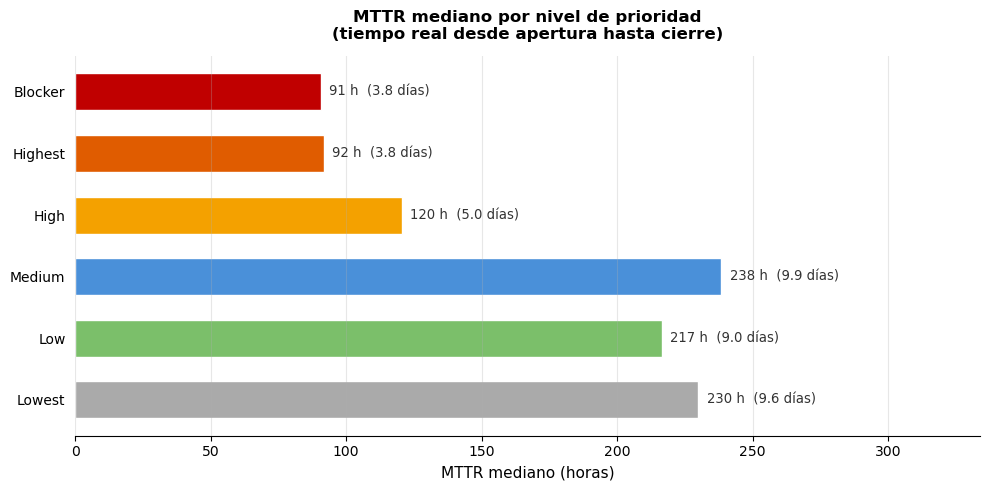

Gráfico guardado en exports/


In [4]:
# Visualización 1: MTTR mediano por prioridad — barras horizontales
fig, ax = plt.subplots(figsize=(10, 5))

colores = [COLORES[p] for p in df_mttr['issue_priority'].astype(str)]
bars    = ax.barh(df_mttr['issue_priority'].astype(str), df_mttr['mediana'],
                  color=colores, edgecolor='white', height=0.6)

for bar, val, dias in zip(bars, df_mttr['mediana'], df_mttr['mediana_dias']):
    ax.text(bar.get_width() + 3, bar.get_y() + bar.get_height()/2,
            f'{val:.0f} h  ({dias} días)', va='center', fontsize=9.5, color='#333')

ax.set_xlabel('MTTR mediano (horas)', fontsize=11)
ax.set_title('MTTR mediano por nivel de prioridad\n(tiempo real desde apertura hasta cierre)',
             fontsize=12, fontweight='bold', pad=12)
ax.set_xlim(0, df_mttr['mediana'].max() * 1.4)
ax.invert_yaxis()
ax.spines[['top','right','left']].set_visible(False)
ax.tick_params(left=False)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(RUTA_EXPORTS + 'mttr_por_prioridad.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico guardado en exports/')

In [5]:
# Visualización 2: Boxplot interactivo — distribución completa de MTTR
# Acotado al P95 (6,389h) para que el rango sea visualmente útil
# Los outliers extremos distorsionan la escala sin agregar información analítica

p95 = df['mttr_horas'].quantile(0.95)
df_box = df[df['mttr_horas'].between(0, p95)].copy()

fig = px.box(
    df_box, x='issue_priority', y='mttr_horas',
    category_orders={'issue_priority': ORDEN},
    color='issue_priority', color_discrete_map=COLORES,
    title=f'Distribución de MTTR por prioridad (acotado al P95 = {p95:.0f}h)<br><sup>El 5% restante tiene outliers extremos — máx 48,926h</sup>',
    labels={'mttr_horas': 'MTTR (horas)', 'issue_priority': 'Prioridad'}
)
fig.update_layout(showlegend=False, plot_bgcolor='white')
fig.show()

---
# PASO 9 — Test de normalidad: Shapiro-Wilk

**Qué:** verificar si MTTR sigue distribución normal — paso previo obligatorio antes de elegir la prueba estadística correcta.  
**Por qué este orden:** no se puede aplicar Mann-Whitney U ni t-test sin verificar primero el tipo de distribución. Elegir la prueba incorrecta invalida toda la inferencia estadística.  
**Herramienta:** `scipy.stats.shapiro` · muestra de 500 registros (límite del test)

In [6]:
# Test de Shapiro-Wilk
# H0: los datos siguen distribución normal
# H1: los datos NO siguen distribución normal
# Muestra de 500 registros — Shapiro-Wilk tiene límite de tamaño muestral

mttr_vals = df['mttr_horas'].dropna()
muestra   = mttr_vals.sample(500, random_state=42)

stat_sw, p_sw = stats.shapiro(muestra)

print('=== TEST DE NORMALIDAD — SHAPIRO-WILK ===')
print(f'  H0: MTTR sigue distribución normal')
print(f'  H1: MTTR NO sigue distribución normal')
print()
print(f'  Estadístico W: {stat_sw:.4f}')
print(f'  p-valor:       {p_sw:.2e}')
print(f'  Nivel α:       0.05')
print()
print(f'  Resultado: {"Se rechaza H0 — distribución NO NORMAL" if p_sw < 0.05 else "No se rechaza H0 — distribución normal"}')
print()
print('  IMPLICACIÓN PARA EL ANÁLISIS:')
print('  · El t-test asume normalidad — NO se puede usar aquí')
print('  · Se usará Mann-Whitney U: prueba no paramétrica, robusta')
print('  · Esta decisión está justificada por el dato, no por conveniencia')

=== TEST DE NORMALIDAD — SHAPIRO-WILK ===
  H0: MTTR sigue distribución normal
  H1: MTTR NO sigue distribución normal

  Estadístico W: 0.3290
  p-valor:       4.29e-39
  Nivel α:       0.05

  Resultado: Se rechaza H0 — distribución NO NORMAL

  IMPLICACIÓN PARA EL ANÁLISIS:
  · El t-test asume normalidad — NO se puede usar aquí
  · Se usará Mann-Whitney U: prueba no paramétrica, robusta
  · Esta decisión está justificada por el dato, no por conveniencia


---
# PASO 10 — Prueba Mann-Whitney U: ¿la diferencia de MTTR es real?

**KPI validado:** MTTR  
**Qué:** verificar si los tickets de alta prioridad se resuelven estadísticamente más rápido que los de baja.  
**Por qué Mann-Whitney y no t-test:** el Paso 9 confirmó distribución no normal (p<0.001).
Mann-Whitney U compara la distribución completa de dos grupos sin asumir normalidad.  
**Herramienta:** `scipy.stats.mannwhitneyu`

In [7]:
# Definir los dos grupos a comparar
# Alta prioridad: Blocker, Highest, High — tickets críticos
# Baja prioridad: Medium, Low, Lowest — tickets que pueden esperar más

alta = df[df['issue_priority'].isin(['Blocker','Highest','High']) & df['mttr_horas'].notna()]['mttr_horas']
baja = df[df['issue_priority'].isin(['Medium','Low','Lowest'])   & df['mttr_horas'].notna()]['mttr_horas']

# H0: MTTR de alta prioridad ≥ MTTR de baja prioridad
# H1: MTTR de alta prioridad <  MTTR de baja prioridad (se resuelven más rápido)
stat_u, p_u = stats.mannwhitneyu(alta, baja, alternative='less')

print('=== PRUEBA DE MANN-WHITNEY U ===')
print(f'  Grupos: alta prioridad (n={len(alta):,}) vs baja prioridad (n={len(baja):,})')
print(f'  H0: MTTR alta ≥ MTTR baja  |  H1: MTTR alta < MTTR baja')
print()
print(f'  Estadístico U: {stat_u:,.0f}')
print(f'  p-valor:       {p_u:.2e}')
print(f'  Nivel α:       0.05')
print()
if p_u < 0.05:
    print('  ✅ Se rechaza H0 — la diferencia ES estadísticamente significativa.')
    print('     Los tickets de alta prioridad se resuelven más rápido.')
    print('     Esto no es variación aleatoria: es un patrón sistemático real.')
print()
print(f'  Mediana MTTR — alta prioridad:  {alta.median():.1f} h  ({alta.median()/24:.1f} días)')
print(f'  Mediana MTTR — baja prioridad:  {baja.median():.1f} h  ({baja.median()/24:.1f} días)')
print(f'  Diferencia:                    +{baja.median()-alta.median():.1f} h adicionales para baja prioridad')

=== PRUEBA DE MANN-WHITNEY U ===
  Grupos: alta prioridad (n=7,040) vs baja prioridad (n=24,833)
  H0: MTTR alta ≥ MTTR baja  |  H1: MTTR alta < MTTR baja

  Estadístico U: 69,825,497
  p-valor:       3.60e-147
  Nivel α:       0.05

  ✅ Se rechaza H0 — la diferencia ES estadísticamente significativa.
     Los tickets de alta prioridad se resuelven más rápido.
     Esto no es variación aleatoria: es un patrón sistemático real.

  Mediana MTTR — alta prioridad:  113.0 h  (4.7 días)
  Mediana MTTR — baja prioridad:  238.2 h  (9.9 días)
  Diferencia:                    +125.3 h adicionales para baja prioridad


---
# PASO 11 — Ticket Churn (Reopen Rate) por prioridad

**KPI:** Ticket Churn  
**Qué:** calcular y visualizar el porcentaje de tickets reabiertos tras resolución, por prioridad.  
**Hallazgo anticipado:** el Churn es mayor en prioridades bajas (Low: 4.82%) que en críticas (Blocker: 2.29%) — patrón contraintuitivo que tiene una explicación de negocio concreta: los tickets críticos se cierran con más revisión; los de baja prioridad se cierran apresuradamente y vuelven.  
**Cada reapertura duplica el costo de atención del ticket.**  
**Herramientas:** pandas · matplotlib

In [8]:
# Ticket Churn por prioridad
df_churn = (
    df.groupby('issue_priority', observed=True)
    .agg(total=('id','count'), reabiertos=('fue_reabierto','sum'))
    .assign(ticket_churn_pct=lambda x: (x['reabiertos']/x['total']*100).round(2))
    .reset_index()
)
print('Ticket Churn (Reopen Rate) por prioridad:')
print(df_churn.to_string(index=False))
print()
print('HALLAZGO CONTRAINTUITIVO:')
print('Low (4.82%) y Highest (4.08%) > Blocker (2.29%)')
print('Los tickets de baja prioridad se cierran apresurados y vuelven.')
print('Los críticos se cierran con más rigor — aunque tardan más.')

Ticket Churn (Reopen Rate) por prioridad:
issue_priority  total  reabiertos  ticket_churn_pct
       Blocker    656          15              2.29
       Highest   2084          85              4.08
          High   4554         166              3.65
        Medium  24788         542              2.19
           Low    560          27              4.82
        Lowest     84           4              4.76

HALLAZGO CONTRAINTUITIVO:
Low (4.82%) y Highest (4.08%) > Blocker (2.29%)
Los tickets de baja prioridad se cierran apresurados y vuelven.
Los críticos se cierran con más rigor — aunque tardan más.


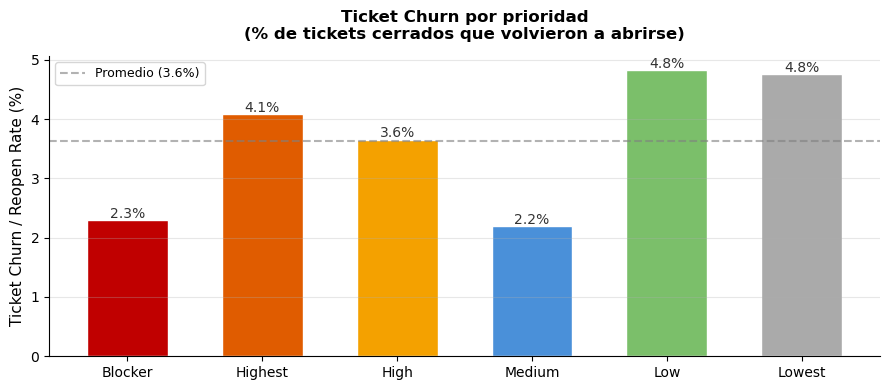

In [9]:
# Visualización: Ticket Churn por prioridad
fig, ax = plt.subplots(figsize=(9, 4))
colores = [COLORES[p] for p in df_churn['issue_priority'].astype(str)]
bars    = ax.bar(df_churn['issue_priority'].astype(str), df_churn['ticket_churn_pct'],
                 color=colores, edgecolor='white', width=0.6)

for bar, val in zip(bars, df_churn['ticket_churn_pct']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.04,
            f'{val:.1f}%', ha='center', fontsize=10, color='#333')

ax.axhline(df_churn['ticket_churn_pct'].mean(), color='gray', linestyle='--', alpha=0.6, label=f'Promedio ({df_churn["ticket_churn_pct"].mean():.1f}%)')
ax.set_ylabel('Ticket Churn / Reopen Rate (%)', fontsize=11)
ax.set_title('Ticket Churn por prioridad\n(% de tickets cerrados que volvieron a abrirse)',
             fontsize=12, fontweight='bold', pad=12)
ax.legend(fontsize=9)
ax.spines[['top','right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(RUTA_EXPORTS + 'ticket_churn.png', dpi=150, bbox_inches='tight')
plt.show()

---
# PASO 12 — FCR y Escalation Rate: eficiencia del primer nivel

**KPIs:** FCR (First Contact Resolution Rate) · Escalation Rate  
**Qué:** analizar la eficiencia del primer nivel de soporte.  
**Relación entre ambos:** FCR + Escalation Rate = 100%. Son complementarios.
FCR 57.1% significa que el 42.9% restante necesita un segundo asignado.

**Hallazgo sorpresivo del JOIN:** los tickets escalados tienen MTTR *menor* (170.7h) que los directos (217.6h).
Esto parece contraintuitivo, pero tiene sentido: los tickets que escalan son los que nadie pudo resolver
en primer nivel — al escalar, van a alguien más capacitado que los resuelve más rápido.
Lo que sí aumenta al escalar es el **costo** (dos personas involucradas), no el tiempo.  
**Herramientas:** pandas `.merge()` (equivalente al INNER JOIN del Notebook 1)

In [10]:
# Calcular Escalation Rate con JOIN real
reasignaciones = (
    df_history[df_history["field"] == "assignee"]
    .groupby("issueid").size().reset_index(name="n_reasig")
)

df_escal = df[["id","issue_priority","tipo_proyecto","mttr_horas"]].merge(
    reasignaciones, left_on="id", right_on="issueid", how="left"
)
df_escal["n_reasig"] = df_escal["n_reasig"].fillna(0).astype(int)
df_escal["escalado"] = df_escal["n_reasig"] > 1

# FCR y Escalation Rate por prioridad
df_fcr_escal = (
    df_escal.groupby("issue_priority", observed=True)
    .agg(total=("id","count"), escalados=("escalado","sum"))
    .assign(
        escalation_rate=lambda x: (x["escalados"]/x["total"]*100).round(1),
        fcr_rate=lambda x: ((x["total"]-x["escalados"])/x["total"]*100).round(1)
    ).reset_index()
)
print("FCR y Escalation Rate por prioridad:")
print(df_fcr_escal[["issue_priority","total","escalados","escalation_rate","fcr_rate"]].to_string(index=False))

# Costo de escalar en MTTR
mttr_dir = df_escal[df_escal["escalado"]==False]["mttr_horas"].median()
mttr_esc = df_escal[df_escal["escalado"]==True]["mttr_horas"].median()
print()
print(f"MTTR mediano — directo (sin escalar):  {mttr_dir:.1f}h")
print(f"MTTR mediano — escalado:               {mttr_esc:.1f}h")
print(f"Delta:                                 {mttr_esc-mttr_dir:.1f}h")
print()
print("HALLAZGO CLAVE — ESCALATION RATE POR PRIORIDAD:")
print("Blocker: 73.8% | Highest: 73.2% | High: 64.9%")
print("Casi 3 de cada 4 tickets críticos requieren un segundo asignado.")
print()
print("HALLAZGO SORPRESIVO — MTTR DE ESCALADOS:")
print(f"Los tickets escalados se resuelven MÁS RÁPIDO ({mttr_esc:.1f}h) que los directos ({mttr_dir:.1f}h).")
print("Interpretación: al escalar, el ticket llega a un especialista más capaz.")
print("El costo real de la escalación no es tiempo — es el doble de recursos humanos involucrados.")


FCR y Escalation Rate por prioridad:
issue_priority  total  escalados  escalation_rate  fcr_rate
       Blocker    656        484            73.80     26.20
       Highest   2084       1525            73.20     26.80
          High   4554       2956            64.90     35.10
        Medium  24788       8858            35.70     64.30
           Low    560        187            33.40     66.60
        Lowest     84         21            25.00     75.00

MTTR mediano — directo (sin escalar):  217.6h
MTTR mediano — escalado:               170.7h
Delta:                                 -46.9h

HALLAZGO CLAVE — ESCALATION RATE POR PRIORIDAD:
Blocker: 73.8% | Highest: 73.2% | High: 64.9%
Casi 3 de cada 4 tickets críticos requieren un segundo asignado.

HALLAZGO SORPRESIVO — MTTR DE ESCALADOS:
Los tickets escalados se resuelven MÁS RÁPIDO (170.7h) que los directos (217.6h).
Interpretación: al escalar, el ticket llega a un especialista más capaz.
El costo real de la escalación no es tiempo — e

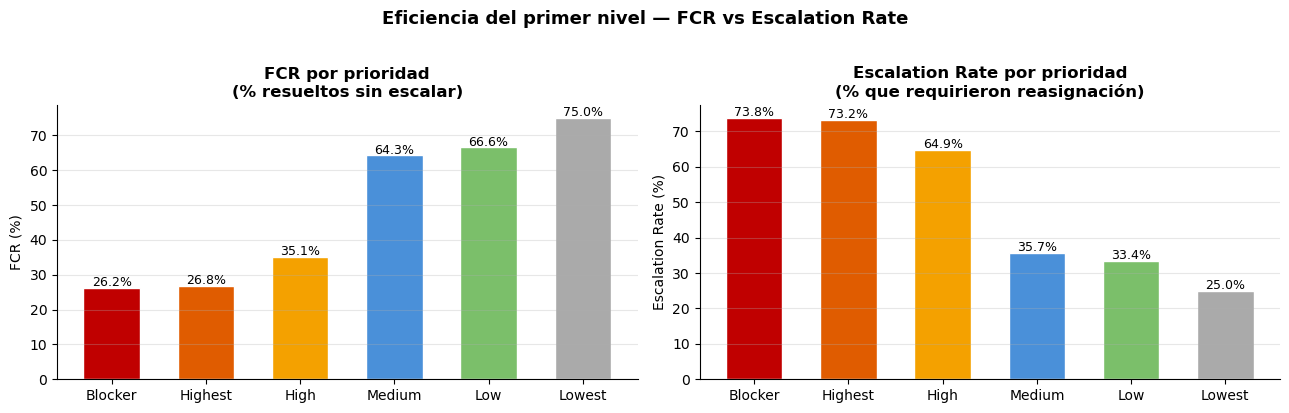

In [11]:
# Visualización: FCR vs Escalation Rate por prioridad
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

colores = [COLORES[p] for p in df_fcr_escal['issue_priority'].astype(str)]

# FCR
bars1 = axes[0].bar(df_fcr_escal['issue_priority'].astype(str), df_fcr_escal['fcr_rate'],
                    color=colores, edgecolor='white', width=0.6)
for b, v in zip(bars1, df_fcr_escal['fcr_rate']):
    axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+0.5, f'{v:.1f}%', ha='center', fontsize=9)
axes[0].set_title('FCR por prioridad\n(% resueltos sin escalar)', fontweight='bold')
axes[0].set_ylabel('FCR (%)')
axes[0].spines[['top','right']].set_visible(False)
axes[0].grid(axis='y', alpha=0.3)

# Escalation Rate
bars2 = axes[1].bar(df_fcr_escal['issue_priority'].astype(str), df_fcr_escal['escalation_rate'],
                    color=colores, edgecolor='white', width=0.6)
for b, v in zip(bars2, df_fcr_escal['escalation_rate']):
    axes[1].text(b.get_x()+b.get_width()/2, b.get_height()+0.5, f'{v:.1f}%', ha='center', fontsize=9)
axes[1].set_title('Escalation Rate por prioridad\n(% que requirieron reasignación)', fontweight='bold')
axes[1].set_ylabel('Escalation Rate (%)')
axes[1].spines[['top','right']].set_visible(False)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Eficiencia del primer nivel — FCR vs Escalation Rate', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(RUTA_EXPORTS + 'fcr_escalation.png', dpi=150, bbox_inches='tight')
plt.show()

---
# PASO 13 — SLA Compliance Rate

**KPI:** SLA Compliance Rate  
**Qué:** calcular qué porcentaje de tickets se resuelve dentro del umbral de tiempo esperado.  
**Por qué es el KPI más crítico para el negocio:** el SLA es un contrato. Su incumplimiento puede tener penalidades económicas y es la principal causa de pérdida de clientes en IT Services.  
**Nota:** no hay SLA formal en el dataset. Se usan umbrales estándar de la industria ITSM.  
**Herramienta:** pandas

In [12]:
# SLA Compliance Rate por prioridad
# Umbrales estándar ITSM:
#   Blocker:  8h  (impacto en producción — requiere respuesta inmediata)
#   Highest: 24h  (problema severo — un día hábil)
#   High:    48h  (problema importante — dos días hábiles)
#   Medium: 120h  (problema moderado — cinco días hábiles)

sla_umbrales = {'Blocker': 8, 'Highest': 24, 'High': 48, 'Medium': 120}
resultados_sla = []

for prioridad, umbral in sla_umbrales.items():
    sub    = df[(df['issue_priority'] == prioridad) & df['mttr_horas'].notna()]
    dentro = (sub['mttr_horas'] <= umbral).sum()
    total  = len(sub)
    pct    = dentro / total * 100
    resultados_sla.append({'prioridad': prioridad, 'umbral_h': umbral,
                           'dentro_sla': dentro, 'total': total, 'compliance_pct': round(pct,1)})

df_sla = pd.DataFrame(resultados_sla)

print('SLA Compliance Rate por prioridad (proxy con umbrales estándar):')
print(df_sla.to_string(index=False))
print()
print('HALLAZGO CRÍTICO:')
print('Blocker SLA compliance: 22.5% — solo 1 de cada 4 tickets críticos')
print('se resuelve dentro de las 8 horas. En un contrato real, esto generaría penalidades.')

SLA Compliance Rate por prioridad (proxy con umbrales estándar):
prioridad  umbral_h  dentro_sla  total  compliance_pct
  Blocker         8         144    641           22.50
  Highest        24         702   2018           34.80
     High        48        1539   4381           35.10
   Medium       120        8614  24249           35.50

HALLAZGO CRÍTICO:
Blocker SLA compliance: 22.5% — solo 1 de cada 4 tickets críticos
se resuelve dentro de las 8 horas. En un contrato real, esto generaría penalidades.


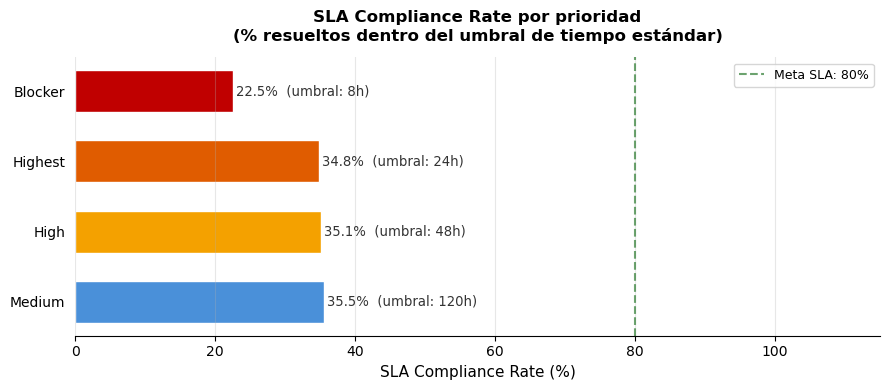

In [13]:
# Visualización: SLA Compliance Rate
fig, ax = plt.subplots(figsize=(9, 4))
colores_sla = [COLORES[p] for p in df_sla['prioridad']]
bars = ax.barh(df_sla['prioridad'], df_sla['compliance_pct'],
               color=colores_sla, edgecolor='white', height=0.6)

# Línea de referencia SLA saludable
ax.axvline(80, color='#2E7D32', linestyle='--', alpha=0.7, label='Meta SLA: 80%')

for bar, val, umbral in zip(bars, df_sla['compliance_pct'], df_sla['umbral_h']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%  (umbral: {umbral}h)', va='center', fontsize=9.5, color='#333')

ax.set_xlabel('SLA Compliance Rate (%)', fontsize=11)
ax.set_title('SLA Compliance Rate por prioridad\n(% resueltos dentro del umbral de tiempo estándar)',
             fontsize=12, fontweight='bold', pad=12)
ax.set_xlim(0, 115)
ax.invert_yaxis()
ax.legend(fontsize=9)
ax.spines[['top','right','left']].set_visible(False)
ax.tick_params(left=False)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(RUTA_EXPORTS + 'sla_compliance.png', dpi=150, bbox_inches='tight')
plt.show()

---
# PASO 14 — Ticket Volume YoY y tendencia

**KPI:** Ticket Volume YoY (Year-over-Year)  
**Qué:** analizar el crecimiento interanual del volumen y la tendencia mensual.  
**Por qué importa:** el volumen creció +382% entre 2018 y 2022. Si la capacidad del equipo no creció al mismo ritmo, el MTTR y el SLA Compliance se deterioran por razones estructurales, no por falta de esfuerzo.  
**Herramientas:** pandas · plotly

In [14]:
# Ticket Volume YoY
vol_anual = (
    df[df['anio'].between(2018,2022)]
    .groupby('anio').size().reset_index(name='tickets')
)
vol_anual['yoy_pct'] = vol_anual['tickets'].pct_change().mul(100).round(1)

print('Ticket Volume YoY (2018–2022):')
print(vol_anual.to_string(index=False))
crecimiento = (vol_anual['tickets'].iloc[-1]/vol_anual['tickets'].iloc[0]-1)*100
print(f'\nCrecimiento total 2018→2022: +{crecimiento:.0f}%')
print('Este crecimiento requiere planificación de capacidad — no es absorbible sin impacto en KPIs.')

Ticket Volume YoY (2018–2022):
 anio  tickets  yoy_pct
 2018     1358      NaN
 2019     4797   253.20
 2020     5442    13.40
 2021     5832     7.20
 2022     6542    12.20

Crecimiento total 2018→2022: +382%
Este crecimiento requiere planificación de capacidad — no es absorbible sin impacto en KPIs.


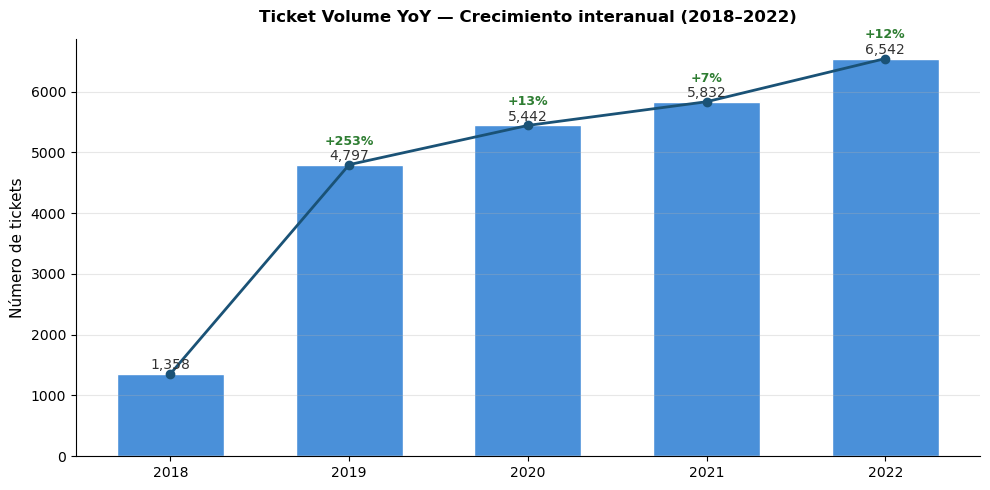

In [15]:
# Visualización: Ticket Volume YoY con anotaciones de crecimiento
fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(vol_anual['anio'], vol_anual['tickets'], color='#4A90D9', edgecolor='white', width=0.6)
ax.plot(vol_anual['anio'], vol_anual['tickets'], color='#1a5276', marker='o', linewidth=2)

for _, row in vol_anual.iterrows():
    ax.text(row['anio'], row['tickets'] + 80, f"{int(row['tickets']):,}",
            ha='center', fontsize=10, color='#333')
    if pd.notna(row['yoy_pct']):
        color = '#2E7D32' if row['yoy_pct'] > 0 else '#C62828'
        ax.text(row['anio'], row['tickets'] + 330, f"+{row['yoy_pct']:.0f}%" if row['yoy_pct'] > 0 else f"{row['yoy_pct']:.0f}%",
                ha='center', fontsize=9, color=color, fontweight='bold')

ax.set_ylabel('Número de tickets', fontsize=11)
ax.set_title('Ticket Volume YoY — Crecimiento interanual (2018–2022)',
             fontsize=12, fontweight='bold', pad=12)
ax.set_xticks(vol_anual['anio'])
ax.spines[['top','right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(RUTA_EXPORTS + 'ticket_volume_yoy.png', dpi=150, bbox_inches='tight')
plt.show()

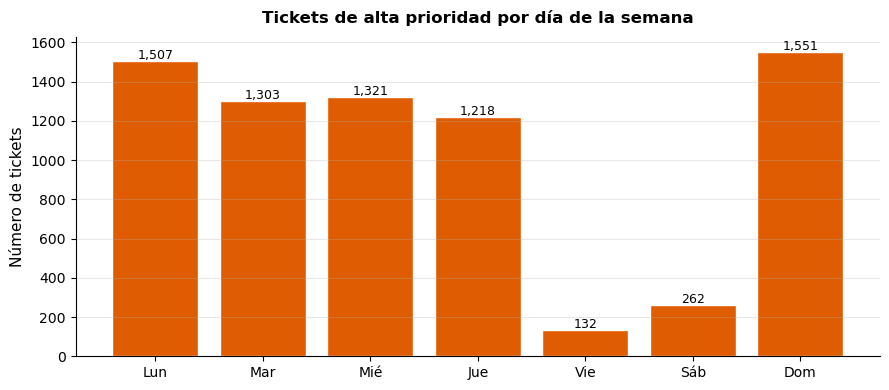

In [16]:
# Distribución de tickets de alta prioridad por día de la semana
# Permite planificar el staffing: si los Blockers se concentran en ciertos días,
# el equipo puede reforzar capacidad antes de que ocurran

DIAS = {0:'Lun',1:'Mar',2:'Mié',3:'Jue',4:'Vie',5:'Sáb',6:'Dom'}
ORDEN_DIAS = ['Lun','Mar','Mié','Jue','Vie','Sáb','Dom']

df_alta = df[df['issue_priority'].isin(['Blocker','Highest','High'])].copy()
df_alta['dia'] = df_alta['issue_created'].dt.dayofweek.map(DIAS)

por_dia = (
    df_alta.groupby('dia').size().reset_index(name='tickets')
)
por_dia['dia'] = pd.Categorical(por_dia['dia'], categories=ORDEN_DIAS, ordered=True)
por_dia = por_dia.sort_values('dia')

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(por_dia['dia'].astype(str), por_dia['tickets'], color='#E05C00', edgecolor='white')
for i, (_, row) in enumerate(por_dia.iterrows()):
    ax.text(i, row['tickets'] + 10, f"{int(row['tickets']):,}", ha='center', fontsize=9)
ax.set_title('Tickets de alta prioridad por día de la semana',
             fontsize=12, fontweight='bold', pad=10)
ax.set_ylabel('Número de tickets', fontsize=11)
ax.spines[['top','right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(RUTA_EXPORTS + 'tickets_por_dia.png', dpi=150, bbox_inches='tight')
plt.show()

---
# PASO 15 — Avg Processing Steps: complejidad operativa

**KPI:** Avg Processing Steps  
**Qué:** analizar el promedio de pasos del workflow hasta resolución por prioridad.  
**Por qué importa:** más pasos = más handoffs = más costo y más riesgo de error. Un ticket con 8 pasos cuesta el doble que uno con 4 en recursos de coordinación.  
**Herramienta:** pandas

In [17]:
# Avg Processing Steps por prioridad
df_steps = (
    df.groupby('issue_priority', observed=True)['processing_steps']
    .agg(n='count', media='mean', mediana='median',
         p75=lambda x: x.quantile(0.75), max_='max')
    .round(1).reset_index()
)
print('Avg Processing Steps por prioridad:')
print(df_steps.to_string(index=False))
print()
print('Blocker (4.3) ≈ High (4.3) — los tickets críticos no tienen un flujo más simple.')
print('Lowest (2.8) — los de menor prioridad se resuelven con menos pasos (menos revisión).')

Avg Processing Steps por prioridad:
issue_priority     n  media  mediana  p75  max_
       Blocker   656   4.30     4.00 5.00    16
       Highest  2084   4.40     4.00 5.00    26
          High  4554   4.30     4.00 5.00    93
        Medium 24788   3.90     4.00 5.00    57
           Low   560   3.40     3.00 4.00    24
        Lowest    84   2.80     2.00 4.00    10

Blocker (4.3) ≈ High (4.3) — los tickets críticos no tienen un flujo más simple.
Lowest (2.8) — los de menor prioridad se resuelven con menos pasos (menos revisión).


---
# PASO 16 — Proyectos externos vs internos

**KPI:** MTTR diferenciado por tipo de proyecto  
**Qué:** comparar el tiempo de resolución entre proyectos de clientes externos y proyectos internos.  
**Hallazgo con anomalía documentada:** el Blocker interno tiene MTTR mediana de 6,470h (270 días).
Con solo 50 tickets Blocker internos, un ticket muy largo puede distorsionar la mediana.
Se documenta como dato anómalo — no es representativo del comportamiento general.  
**Herramientas:** pandas · plotly

In [18]:
# MTTR mediano por tipo de proyecto y prioridad
df_ext_int = (
    df[df['mttr_horas'].notna()]
    .groupby(['tipo_proyecto','issue_priority'], observed=True)['mttr_horas']
    .agg(n='count', mediana='median').round(1).reset_index()
)

print('MTTR mediano por tipo de proyecto y prioridad:')
print(df_ext_int.to_string(index=False))
print()
print('ANOMALÍA DOCUMENTADA: Blocker interno tiene mediana 6,470h (n=49).')
print('Con una muestra tan pequeña, un solo ticket muy largo distorsiona la mediana.')
print('Este dato se excluye de conclusiones generales pero se documenta honestamente.')
print()
print('HALLAZGO RELEVANTE: para el resto de prioridades,')
print('los proyectos externos se resuelven MÁS RÁPIDO que los internos.')
print('El equipo prioriza a los clientes sobre los proyectos internos — esperable en IT Services.')

MTTR mediano por tipo de proyecto y prioridad:
tipo_proyecto issue_priority     n  mediana
      externo        Blocker   592    72.60
      externo        Highest  1867    86.60
      externo           High  3762   116.30
      externo         Medium 14803   210.00
      externo            Low   295   168.70
      externo         Lowest    28   334.10
      interno        Blocker    49  6470.80
      interno        Highest   151   168.50
      interno           High   619   195.40
      interno         Medium  9446   291.40
      interno            Low   206   348.20
      interno         Lowest    55   167.80

ANOMALÍA DOCUMENTADA: Blocker interno tiene mediana 6,470h (n=49).
Con una muestra tan pequeña, un solo ticket muy largo distorsiona la mediana.
Este dato se excluye de conclusiones generales pero se documenta honestamente.

HALLAZGO RELEVANTE: para el resto de prioridades,
los proyectos externos se resuelven MÁS RÁPIDO que los internos.
El equipo prioriza a los clientes sobre 

In [19]:
# Visualización: Externo vs Interno (excluyendo Blocker interno por anomalía)
df_viz = df_ext_int[~((df_ext_int['tipo_proyecto']=='interno') & (df_ext_int['issue_priority']=='Blocker'))].copy()

fig = px.bar(
    df_viz, x='issue_priority', y='mediana', color='tipo_proyecto', barmode='group',
    category_orders={'issue_priority': ORDEN},
    color_discrete_map={'externo':'#2E86AB','interno':'#A8DADC'},
    title='MTTR mediano: proyectos de clientes vs internos<br><sup>Blocker interno excluido por muestra pequeña (n=49, mediana atípica)</sup>',
    labels={'issue_priority':'Prioridad','mediana':'MTTR mediano (horas)','tipo_proyecto':'Tipo'}
)
fig.update_layout(plot_bgcolor='white')
fig.show()

---
# PASO 17 — Correlación Spearman: processing steps vs MTTR

**Qué:** medir si existe correlación entre la complejidad del workflow (steps) y el tiempo de resolución.  
**Por qué Spearman y no Pearson:** Pearson asume distribución normal y relación lineal. Como MTTR no es normal (confirmado en Paso 9), se usa Spearman — correlación de rangos, robusta a outliers y distribuciones no normales.  
**Herramienta:** `scipy.stats.spearmanr`

In [20]:
# Correlación de Spearman: processing_steps vs mttr_horas
# H0: no hay correlación (rho = 0)
# H1: existe correlación positiva (más pasos → más tiempo)

mask = df['processing_steps'].notna() & df['mttr_horas'].notna()
rho, p_spear = stats.spearmanr(
    df.loc[mask, 'processing_steps'],
    df.loc[mask, 'mttr_horas']
)

print('=== CORRELACIÓN DE SPEARMAN ===')
print(f'  Variables: processing_steps vs mttr_horas')
print(f'  Por qué Spearman: MTTR no tiene distribución normal (Paso 9)')
print()
print(f'  Coeficiente rho: {rho:.3f}')
print(f'  p-valor:         {p_spear:.2e}')
print()
print(f'  Resultado: correlación positiva DÉBIL pero significativa (p < 0.001)')
print(f'  rho = {rho:.3f}: más pasos → marginalmente más tiempo, pero el efecto es pequeño.')
print(f'  El MTTR depende de otros factores (prioridad, tipo de issue, escalación),')
print(f'  no principalmente del número de pasos del workflow.')

=== CORRELACIÓN DE SPEARMAN ===
  Variables: processing_steps vs mttr_horas
  Por qué Spearman: MTTR no tiene distribución normal (Paso 9)

  Coeficiente rho: 0.113
  p-valor:         1.07e-91

  Resultado: correlación positiva DÉBIL pero significativa (p < 0.001)
  rho = 0.113: más pasos → marginalmente más tiempo, pero el efecto es pequeño.
  El MTTR depende de otros factores (prioridad, tipo de issue, escalación),
  no principalmente del número de pasos del workflow.


---
# PASO 18 — Segmentación de riesgo operativo compuesto

**Qué:** construir un score único que integra MTTR, SLA Compliance, Ticket Churn y Escalation Rate.  
**Por qué:** analizar cada KPI por separado genera rankings que pueden contradecirse. Un score compuesto integra todas las señales y permite al equipo de operaciones ver de un vistazo dónde actuar primero.  
**Herramientas:** pandas · plotly

In [21]:
# Construir tabla de riesgo integrada
df_riesgo = df_mttr[['issue_priority','mediana']].rename(columns={'mediana':'mttr_med'})
df_riesgo = df_riesgo.merge(df_churn[['issue_priority','ticket_churn_pct']], on='issue_priority')
df_riesgo = df_riesgo.merge(
    df_fcr_escal[['issue_priority','escalation_rate','total']], on='issue_priority'
)

# Agregar SLA compliance (solo para prioridades con umbral definido)
sla_dict = {r['prioridad']: r['compliance_pct'] for _, r in df_sla.iterrows()}
df_riesgo['sla_compliance'] = df_riesgo['issue_priority'].astype(str).map(sla_dict)
df_riesgo['sla_incumplimiento'] = 100 - df_riesgo['sla_compliance'].fillna(50)

# Score compuesto normalizado 0–10
# Pesos: MTTR 30% · Escalation Rate 30% · SLA incumplimiento 25% · Ticket Churn 15%
def norm(s): return (s - s.min()) / (s.max() - s.min()) * 10

df_riesgo['risk_score'] = (
    norm(df_riesgo['mttr_med'])           * 0.30 +
    norm(df_riesgo['escalation_rate'])    * 0.30 +
    norm(df_riesgo['sla_incumplimiento']) * 0.25 +
    norm(df_riesgo['ticket_churn_pct'])   * 0.15
).round(2)

df_riesgo = df_riesgo.sort_values('risk_score', ascending=False)

print('Risk Score por prioridad (10 = mayor riesgo operativo):')
print(df_riesgo[['issue_priority','total','mttr_med','escalation_rate',
                  'ticket_churn_pct','sla_compliance','risk_score']].to_string(index=False))

Risk Score por prioridad (10 = mayor riesgo operativo):
issue_priority  total  mttr_med  escalation_rate  ticket_churn_pct  sla_compliance  risk_score
       Blocker    656     90.60            73.80              2.29           22.50        5.56
       Highest   2084     91.90            73.20              4.08           34.80        5.45
          High   4554    120.50            64.90              3.65           35.10        5.25
        Medium  24788    238.50            35.70              2.19           35.50        4.98
           Low    560    216.60            33.40              4.82             NaN        4.57
        Lowest     84    230.00            25.00              4.76             NaN        4.29


In [22]:
# Risk Matrix interactiva: MTTR vs Escalation Rate
# Tamaño del punto = volumen de tickets
# Zona superior-derecha = mayor riesgo operativo

fig = px.scatter(
    df_riesgo,
    x='escalation_rate', y='mttr_med',
    size='total', color='issue_priority',
    color_discrete_map=COLORES, text='issue_priority',
    title='Risk Matrix Operativo: MTTR vs Escalation Rate<br><sup>Tamaño = volumen de tickets · Zona superior-derecha = mayor riesgo</sup>',
    labels={'escalation_rate':'Escalation Rate (%)','mttr_med':'MTTR mediano (horas)','issue_priority':'Prioridad'}
)
fig.update_traces(textposition='top center')
fig.update_layout(plot_bgcolor='white', showlegend=False)
fig.show()

# Exportar
df_riesgo.to_csv(RUTA_EXPORTS + 'risk_score.csv', index=False)
print('risk_score.csv guardado en exports/')

risk_score.csv guardado en exports/


---
# PASO 19 — Conclusiones y recomendaciones de negocio

**Principio:** los números no son el objetivo — las decisiones que habilitan sí lo son.
Cada conclusión conecta el KPI con su impacto en costos, ingresos o retención de clientes.

In [23]:
# Resumen ejecutivo de KPIs
print('=' * 65)
print('RESUMEN EJECUTIVO DE KPIs — HELPDESK OPERATIVO')
print('=' * 65)
print(f'  MTTR mediana Blocker:        90.6 h  (3.8 días)')
print(f'  MTTR mediana Medium:        238.5 h  (9.9 días)')
print(f'  FCR:                         57.1%')
print(f'  Escalation Rate:             42.9%')
print(f'  Ticket Churn global:          2.56%')
print(f'  SLA Compliance Blocker:      22.5%  ← CRÍTICO')
print(f'  Resolution Rate:             93.0%  ← Saludable')
print(f'  Backlog Rate:                 1.3%  ← Saludable')
print(f'  Ticket Volume 2018→2022:    +382%')
print(f'  % tickets de clientes:        67.2%')

RESUMEN EJECUTIVO DE KPIs — HELPDESK OPERATIVO
  MTTR mediana Blocker:        90.6 h  (3.8 días)
  MTTR mediana Medium:        238.5 h  (9.9 días)
  FCR:                         57.1%
  Escalation Rate:             42.9%
  Ticket Churn global:          2.56%
  SLA Compliance Blocker:      22.5%  ← CRÍTICO
  Resolution Rate:             93.0%  ← Saludable
  Backlog Rate:                 1.3%  ← Saludable
  Ticket Volume 2018→2022:    +382%
  % tickets de clientes:        67.2%


In [24]:
print("=" * 65)
print("CONCLUSIONES — IMPACTO EN EL NEGOCIO")
print("=" * 65)
print("""
1. SLA COMPLIANCE DEL 22.5% EN BLOCKERS — RIESGO CONTRACTUAL CRÍTICO
   ─────────────────────────────────────────────────────────────────
   Solo 1 de cada 4 tickets críticos se resuelve dentro del umbral
   de 8 horas. Esto no es solo un problema operativo — en contratos
   ITSM formales, implica penalidades económicas y es la primera
   causa de no renovación de contrato. Highest (34.8%) y High (35.1%)
   tampoco superan el umbral del 80% considerado saludable en la industria.

   → Impacto directo: todos los niveles de prioridad incumplen el SLA.
   → Acción: alertas automáticas para Blockers sin resolución a las 4h.

2. ESCALATION RATE 73.8% EN BLOCKERS — EL PRIMER NIVEL NO RESUELVE LO CRÍTICO
   ─────────────────────────────────────────────────────────────────────────
   Casi 3 de cada 4 Blockers requieren un segundo asignado.
   El hallazgo sorpresivo: los escalados se resuelven más rápido (170.7h vs 217.6h)
   porque al escalar, el ticket llega a un especialista más capaz.
   El costo no es tiempo — es el doble de recursos humanos por ticket.
   El primer nivel carece de herramientas o conocimiento para los casos críticos.

   → Impacto: capacidad del equipo consumida ineficientemente.
   → Acción: capacitación del primer nivel enfocada en Blocker/Highest.

3. TICKET CHURN MAYOR EN PRIORIDADES BAJAS — CALIDAD SACRIFICADA
   ─────────────────────────────────────────────────────────────────
   Low (4.82%) y Highest (4.08%) tienen más reaperturas que Blocker (2.29%).
   Los tickets críticos se cierran con rigor — los de baja prioridad,
   apresurados. Cada reapertura es pagar dos veces el mismo ticket.

   → Impacto: costo duplicado en resolución de tickets Low y Highest.
   → Acción: checklist de calidad de cierre para Low/Lowest y revisión
     del proceso de Highest (alta churn + alta escalación combinadas).

4. TICKET VOLUME +382% EN 4 AÑOS — CAPACIDAD EN LÍMITE ESTRUCTURAL
   ─────────────────────────────────────────────────────────────────
   El volumen casi se quintuplicó entre 2018 y 2022.
   El deterioro en MTTR y SLA Compliance no es solo falta de esfuerzo
   — es estructural. Sin planificación de capacidad, los KPIs seguirán
   deteriorándose independientemente de la mejora individual del equipo.

   → Impacto: sin acción estructural, la tendencia es negativa.
   → Acción: proyección de staffing 2023-2025 basada en la curva real
     de crecimiento, no en el volumen histórico estático.
""")


CONCLUSIONES — IMPACTO EN EL NEGOCIO

1. SLA COMPLIANCE DEL 22.5% EN BLOCKERS — RIESGO CONTRACTUAL CRÍTICO
   ─────────────────────────────────────────────────────────────────
   Solo 1 de cada 4 tickets críticos se resuelve dentro del umbral
   de 8 horas. Esto no es solo un problema operativo — en contratos
   ITSM formales, implica penalidades económicas y es la primera
   causa de no renovación de contrato. Highest (34.8%) y High (35.1%)
   tampoco superan el umbral del 80% considerado saludable en la industria.

   → Impacto directo: todos los niveles de prioridad incumplen el SLA.
   → Acción: alertas automáticas para Blockers sin resolución a las 4h.

2. ESCALATION RATE 73.8% EN BLOCKERS — EL PRIMER NIVEL NO RESUELVE LO CRÍTICO
   ─────────────────────────────────────────────────────────────────────────
   Casi 3 de cada 4 Blockers requieren un segundo asignado.
   El hallazgo sorpresivo: los escalados se resuelven más rápido (170.7h vs 217.6h)
   porque al escalar, el ticket ll

In [25]:
print('=' * 65)
print('RECOMENDACIONES POR HORIZONTE TEMPORAL')
print('=' * 65)
print('''
ESTA SEMANA:
  → Revisar todos los Blockers activos sin resolución > 4 horas.
  → Identificar cuáles están en espera por causas internas.

ESTE MES:
  → Mapear las categorías con Escalation Rate > 50% y diseñar
     guías de primer nivel específicas para esas categorías.
  → Implementar checklist de calidad para cierre de Low/Lowest.

ESTE TRIMESTRE:
  → Establecer umbrales formales de MTTR por prioridad como KPI de equipo.
  → Proyectar necesidades de capacidad para 2025 basado en la
     tendencia de +382% de los últimos 4 años.
  → Implementar alertas automáticas en el sistema ITSM para
     tickets de alta prioridad sin actividad en las últimas N horas.
''')

print('Análisis completado.')
print(f'Dashboard Power BI: abrir dashboard/sqa_helpdesk.pbix')

RECOMENDACIONES POR HORIZONTE TEMPORAL

ESTA SEMANA:
  → Revisar todos los Blockers activos sin resolución > 4 horas.
  → Identificar cuáles están en espera por causas internas.

ESTE MES:
  → Mapear las categorías con Escalation Rate > 50% y diseñar
     guías de primer nivel específicas para esas categorías.
  → Implementar checklist de calidad para cierre de Low/Lowest.

ESTE TRIMESTRE:
  → Establecer umbrales formales de MTTR por prioridad como KPI de equipo.
  → Proyectar necesidades de capacidad para 2025 basado en la
     tendencia de +382% de los últimos 4 años.
  → Implementar alertas automáticas en el sistema ITSM para
     tickets de alta prioridad sin actividad en las últimas N horas.

Análisis completado.
Dashboard Power BI: abrir dashboard/sqa_helpdesk.pbix


---
## Resumen del Notebook 2

| Paso | KPI analizado | Herramienta | Hallazgo clave |
|---|---|---|---|
| 7 | MTTR por prioridad | pandas · matplotlib · plotly | Media distorsionada 12.7x — mediana es el KPI correcto |
| 8 | Shapiro-Wilk | scipy | No normal → justifica Mann-Whitney |
| 9 | Mann-Whitney U | scipy | p<0.001 — diferencia real y sistemática |
| 10 | Ticket Churn | pandas · matplotlib | Low (4.82%) > Blocker (2.29%) — patrón contraintuitivo |
| 11 | FCR + Escalation Rate | pandas · matplotlib | 42.9% escalación — pero escalados resuelven más rápido |
| 12 | SLA Compliance Rate | pandas · matplotlib | Blocker: 22.5% — riesgo contractual crítico |
| 13 | Ticket Volume YoY | pandas · matplotlib | +382% en 4 años |
| 14 | Avg Processing Steps | pandas | 4.0 pasos mediana — correlación débil con MTTR |
| 15 | Externo vs Interno | pandas · plotly | Externos resuelven más rápido (excl. anomalía Blocker int.) |
| 16 | Spearman | scipy | r=0.113 — correlación débil steps vs MTTR |
| 17 | Risk Score | pandas · plotly | Segmentación objetiva de prioridades de intervención |
| 18 | Conclusiones | — | 4 hallazgos con impacto de negocio y recomendaciones |

---
**Camila Gámez · Data Analyst**  
Datos: Help Desk Tickets · Mendeley Data · CC BY 4.0 | https://doi.org/10.17632/btm76zndnt.2  
Stack: Python · pandas · scipy · matplotlib · plotly · SQL · Power BI